#### C. Implementation of the RSA function and its inverse

In [24]:
import os                                                            # For navegation in the file folders.
import secrets                                                       # To use entropy for true randomness.
from aux_funcs import *                                              # Auxiliar functions for the project.
from cryptography.hazmat.primitives.asymmetric import rsa            # For generating keys.
from cryptography.hazmat.primitives import hashes                    # Function H(n, r).
import numpy as np                                                   # Para calculos de desvio padrao e intervalos de confiança previsos
import matplotlib.pyplot as plt                                      # Para gerar graficos
import seaborn as sns                                                # Para gerar melhor visualizaçao nos gráficos
import pandas as pd

We start by creating the functions that will mask and unmask our private key. For the encryption, we use the formula:

**Enc(public_key, r_int) = r_int ^ e (mod n)**, where e is the exponent and n is the public number.



And, for the inverse function that decrypts, we use the formula:

**Dec(private_key, c_r) = c_r ^ d (mod n)**, where d is the number such that e * d (mod v) = 1

In [25]:
def rsa_trapdoor_permutation(public_key, r_int):                     # Pure RSA.
    e = public_key.public_numbers().e
    n = public_key.public_numbers().n
    return pow(r_int, e, n)

def rsa_inverse_trapdoor(private_key, c_r):                          # Inverse function of the one above.
    d = private_key.private_numbers().d
    n = private_key.private_numbers().public_numbers.n
    return pow(c_r, d, n)

Having the RSA functions ready, we can now define a way to encrypt and decrypt a message. The next function receives a public key and a message in its original state and transforms it into ciphertext:

1. Start by getting the number n from our public key. 
2. Randomize a number r to be encrypted, which must be smaller than n so that, when reversing (mod n), we know there is only one possible value for r.
3. Apply the trapdoor permutation to encrypt.
4. Transform r from bits to bytes, so that we can apply SHA 256 on it.
5. Divide message into blocks of 32 bytes.
6. Hash each block, measuring the hashing time.
6. Add the ciphertext block to our group of blocks, applying an XOR with the original block.

In [26]:
def custom_encrypt_decrypt(arguments):
    private_key, public_key, message, mode, r = arguments[0], arguments[1], arguments[2], arguments[3], arguments[4]
    l_size = 32                                                          # SHA 256 output size
    ciphertext_blocks = []    
    if (mode == "Encrypting"):  
        enc_message = message
        rsa_r = rsa_trapdoor_permutation(public_key, r)                  # STEP 3.: Apply the trapdoor permutation to r
        rsa_r_bytes = rsa_r.to_bytes(256, 'big')                         # STEP 4.1.: Transform encrypted r from bits into bytes (2048 bits = 256 bytes)
        ciphertext_blocks += [rsa_r_bytes]     
        r_bytes = r.to_bytes(256, 'big')                                 # STEP 4.2.: Transform original r from bits into bytes, to use in hashing operation

    elif (mode == "Decrypting"):
        int_r = rsa_inverse_trapdoor(private_key, int.from_bytes(message[:256], 'big'))
        r_bytes = int_r.to_bytes(256, 'big')
        enc_message = message[256:]
        #print(f"O R É: {int_r}")
    
    hash_time = 0
    for i in range(0, len(enc_message), l_size):                
        block_index = i // l_size
        chunk = enc_message[i : i + l_size]                                  # STEP 5.: Divide our message into blocks of 32 bytes
        
        digest = hashes.Hash(hashes.SHA256())              
                                                                         # STEP 6.: Hash each block, measuring the hashing time
        hash_update_time = measure_performance_time(digest.update, block_index.to_bytes(4, 'big') + r_bytes)[0]
        hash_finalize_time, block_with_hash = measure_performance_time(digest.finalize)
        hash_time += hash_update_time + hash_finalize_time
        
        ciphertext_blocks.append(xor_bytes(chunk, block_with_hash))      # STEP 7.: Apply XOR between original block and hashed block, and append to ciphertext

    return b"".join(ciphertext_blocks), hash_time                    # Return the full ciphertext and the hashing time, for future performance analysis

Now, we simply need to generate the private key and its corresponding public key, to perform encryption and decryption.

In [27]:
private_key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
public_key = private_key.public_key()
n = public_key.public_numbers().n                                # STEP 1.: Get public number n to generate r
r = secrets.randbelow(n)                                         # STEP 2.: Randomize a number r to be encrypted

Which leaves us ready to encrypt our files using that same public key. We start by using the function get_files (available in file aux_func.py), which allows us to choose a file size to test our RSA function on, and then returns 10 files of that size and the path to the corresponding parent folder.

In [28]:
def main(mode, base_dir, file_size):
    all_files, folder_path = get_files(base_dir, file_size, mode)              # Get 10 files of a chosen size, the path of their parent folder and that same chosen size.
    total_time = 0
    rsa_times = []
    hash_times = []
    #print(f"\n{mode} {len(all_files)} files from folder '{file_size}'...")
    #print(f"{'File':<20} | {'Size':<10} | {'Hash Time (s)':<12} | {'RSA Time (s)':<12}")
    #print("-" * 65)
    if (all_files):
        for file_name in all_files:                                      # For each of the files, encrypt.
            file_path = os.path.join(folder_path, file_name)

            with open(file_path, "rb") as f: 
                data = f.read()
                                                                     # Measure the time of encryption for future performance analysis.
            rsa_time, result = measure_performance_time(custom_encrypt_decrypt, [private_key, public_key, data, mode, r])
            ciphertext, hash_time = result
            rsa_times += [rsa_time]
            hash_times += [hash_time]
            total_time += rsa_time                                                      # Save the encrypted files in a new folder.        
            output_dir = save_in_results(ciphertext, base_dir, file_size, file_name, mode)
            #print(f"{file_name:<20} | {len(data):>10} | {hash_time:12.6f} | {rsa_time:12.6f}")
            #print("-" * 65)
        
        #print(f"Total time for folder {file_size}: {total_time:.6f} seconds")
        #print(f"Files saved in: {output_dir}\n")
    else: print("The folder is empty.")
    return rsa_times, hash_times

In [29]:
base_dir = os.getcwd()
main("Encrypting", base_dir, "8")

([0.0004775999113917351,
  0.0006081999745219946,
  0.000569300027564168,
  0.00027600000612437725,
  0.00030319998040795326,
  0.00028469995595514774,
  0.00029019988141953945,
  0.00031020003370940685,
  0.00028540007770061493,
  0.0002639000304043293],
 [3.490014933049679e-05,
  1.7399899661540985e-05,
  1.6600126400589943e-05,
  9.200070053339005e-06,
  1.3200100511312485e-05,
  1.0200077667832375e-05,
  9.999843314290047e-06,
  1.0499963536858559e-05,
  1.3299984857439995e-05,
  8.699949830770493e-06])

In [30]:
main("Decrypting", base_dir, "8")

([0.037854199996218085,
  0.034402099903672934,
  0.04094180022366345,
  0.04782159999012947,
  0.058581499848514795,
  0.054645200027152896,
  0.03780999989248812,
  0.026597100077196956,
  0.044749499997124076,
  0.0425352999009192],
 [1.0599847882986069e-05,
  1.6100239008665085e-05,
  1.4000339433550835e-05,
  1.550000160932541e-05,
  1.1500203981995583e-05,
  2.530030906200409e-05,
  1.0699965059757233e-05,
  1.009996049106121e-05,
  1.5199882909655571e-05,
  1.009996049106121e-05])

With these results, we can now make a thorough analysis of the performance of our program. Let's start by comparing the execution times of our RSA-based encryption for each of the file sizes.

In [31]:
sizes = ["8", "64", "512", "4096", "32768", "262144", "2097152"]
results = {size: {} for size in sizes}

for size in sizes:
        for i in range(0,10):
            rsa_enc, hash_enc = main("Encrypting", base_dir, size)
            rsa_dec, hash_dec = main("Decrypting", base_dir, size)
            results[size][i] = {'RSA Encryption': rsa_enc[i], "Hash Encryption": hash_enc[i], 'RSA Decryption': rsa_dec[i], "Hash Decryption": hash_dec[i]}
        
data_pd = [] #dataframe

for size, files in results.items(): #loop de tamanhos e arquivos
    for file_index, metrics in files.items(): #loop das metricas por aquivo
        for operation, times in metrics.items(): # faz tanto para encriptar quando decriptar
                data_pd.append({
                    "Size_Bytes": int(size),
                    "Filename": "file_" + str(file_index+1) + ".txt",
                    "Execution_Time": times,
                    "Operation": operation # Coluna nova para separar no gráfico
                })

df_data = pd.DataFrame(data_pd) #DataFrame final para exportação no pandas
df_data_RSA = df_data[df_data['Operation'].str.startswith("R")]
df_data_SHA = df_data[df_data['Operation'].str.startswith("H")]

C:\Users\USER\AppData\Local\Temp\ipykernel_12304\1632723619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data_RSA['Execution_Time_us'] = df_data_RSA['Execution_Time'] * 1_000_000


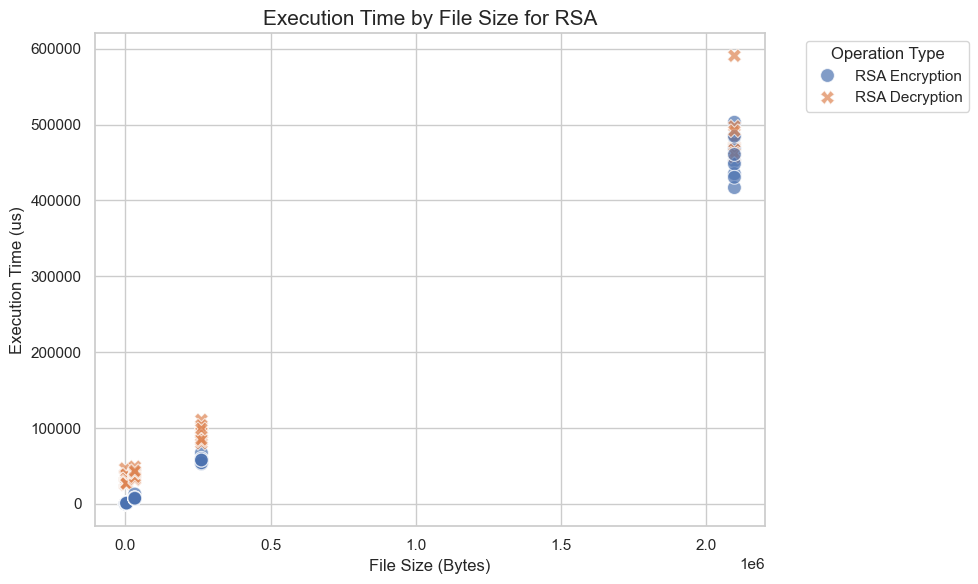

In [37]:
df_data_RSA['Execution_Time_us'] = df_data_RSA['Execution_Time'] * 1_000_000

# 3. Configuração do estilo visual
sns.set_theme(style="whitegrid") # Fundo limpo com grades
plt.figure(figsize=(10, 6))      # Define o tamanho da imagem

# 4. Criação do Scatter Plot (Gráfico de Dispersão)
plot = sns.scatterplot(
    data=df_data_RSA, 
    x='Size_Bytes', 
    y='Execution_Time_us', 
    hue='Operation',    # Cores diferentes para cada operação
    style='Operation',  # Marcadores diferentes para cada operação
    s=100,                   # Tamanho dos pontos
    alpha=0.7                # Transparência para ver sobreposições
)

# 5. Customização de títulos e eixos
plt.title('Execution Time by File Size for RSA', fontsize=15)
plt.xlabel('File Size (Bytes)', fontsize=12)
plt.ylabel('Execution Time (us)', fontsize=12)

# 6. Ajuste da legenda
plt.legend(title='Operation Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

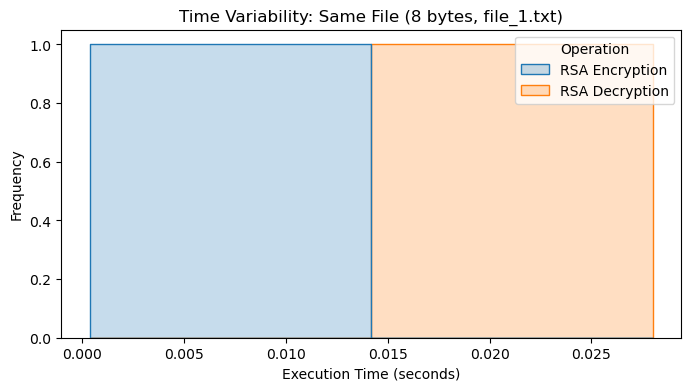

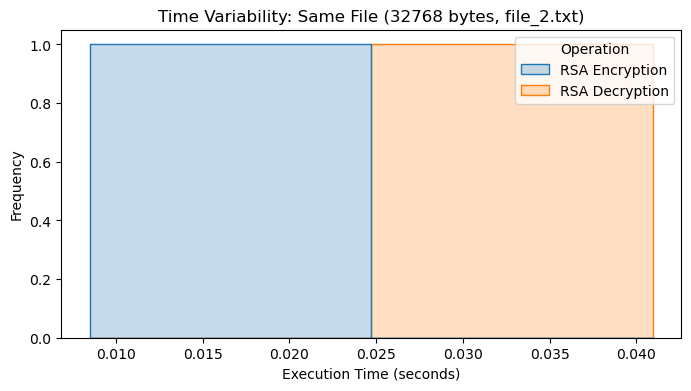

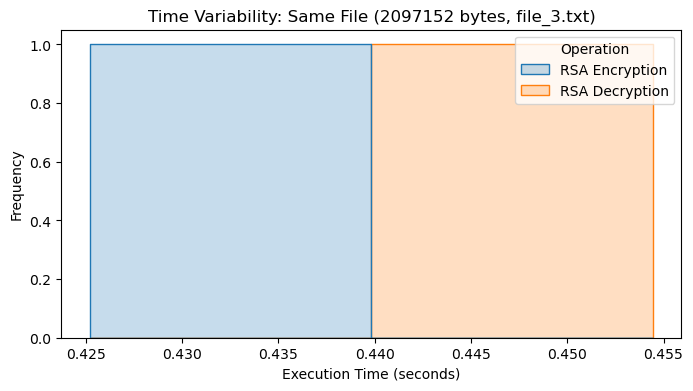

In [ ]:
plot_variation_same_file(df_data_RSA,8,'file_1.txt')
plot_variation_same_file(df_data_RSA,32768, 'file_2.txt')
plot_variation_same_file(df_data_RSA,2097152,'file_3.txt')

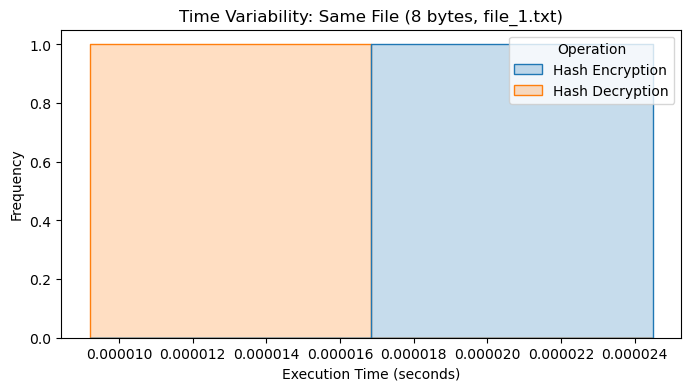

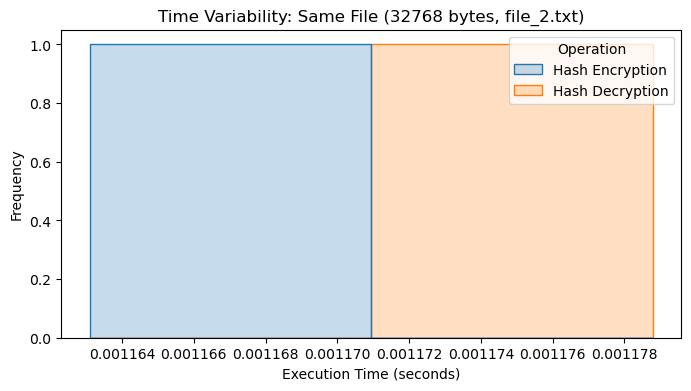

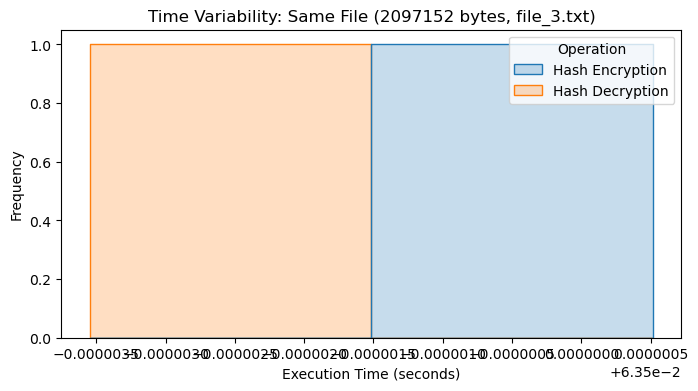

In [ ]:
plot_variation_same_file(df_data_SHA,8,'file_1.txt')
plot_variation_same_file(df_data_SHA,32768, 'file_2.txt')
plot_variation_same_file(df_data_SHA,2097152,'file_3.txt')